# Análisis de clustering para la identificación de perfiles financieros de las IPS en Colombia

##### Objetivo : Aplicar tecnicas de mineria de datos para para identificar y analizar grupos de Instituciones Prestadoras de Servicios de Salud (IPS) en Colombia con comportamientos financieros y operativos similares, a partir de variables económicas, administrativas y de cobertura.

## 1. Carga del Dataset y exploracion inicial

In [6]:
# importar librerias necesarias para carga de datas
import pandas as pd

In [7]:
# cargar y leer dataset
df = pd.read_csv("../Datas/ips_info_2023.csv")
df.head()

,NumeroIdentificacion,NombrePrestador,NaturalezaJuridica,ESE,DepartamentoPrestador,MunicipioCode,MunicipioPrestador,CantMunicipios,CantSedes,ACTIVOS,RankActivos,PASIVOS,PATRIMONIO,INGRESOS,RankIngresos,GASTOS,COSTOS,UTILIDADES,PERIODO,MargenNeto%
0,800149384,CLINICA COLSANITAS S A,Privada,NO,ANTIOQUIA,5001,MEDELLÍN,26,98,1434760000000,2,838391000000,596368000000,1974800000000,1,401547280019,1563560000000,9692719981,2023,"0,49"
1,890324177,FUNDACION VALLE DEL LILI,Privada,NO,VALLE DEL CAUCA,76001,CALI,2,7,1725030000000,1,751848000000,973178000000,1456430000000,2,262011830469,1204890000000,-10466830469,2023,"-0,72"
2,860007336,CAJA COLOMBIANA DE SUBSIDIO FAMILIAR COLSUBSIDIO,Privada,NO,BOGOTÁ D.C,11001,BOGOTÁ,18,67,844789000000,14,591994000000,252796000000,1282110000000,3,396044530588,864233000000,21834469412,2023,"1,70301061624978"
3,900580962,DISFARMA G.C. S.A.S.,Privada,NO,SANTANDER,68276,FLORIDABLANCA,1,1,459941000000,42,274707000000,185234000000,1258730000000,4,133910981032,1085480000000,39340018968,2023,"3,13"
4,811007832,SERVICIOS DE SALUD IPS SURAMERICANA S.A.S,Privada,NO,ANTIOQUIA,5001,MEDELLÍN,21,75,345862000000,66,289744000000,56117757849,1075100000000,5,333471004595,734280000000,7350995405,2023,"0,68"


#### Analisis
##### Se identifica que dataset reune informacion financiera y operativa de las IPS en Colombia durante el periodo 2023, cada fila representando una institucion prestadora de servicios de salud

In [8]:
# imprimir las columnas y el tipo de varibles que tiene el dataset
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5530 entries, 0 to 5529
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   NumeroIdentificacion   5530 non-null   int64
 1   NombrePrestador        5530 non-null   str  
 2   NaturalezaJuridica     5530 non-null   str  
 3   ESE                    5530 non-null   str  
 4   DepartamentoPrestador  5530 non-null   str  
 5   MunicipioCode          5530 non-null   int64
 6   MunicipioPrestador     5530 non-null   str  
 7   CantMunicipios         5530 non-null   int64
 8   CantSedes              5530 non-null   int64
 9   ACTIVOS                5530 non-null   int64
 10  RankActivos            5530 non-null   int64
 11  PASIVOS                5530 non-null   int64
 12  PATRIMONIO             5530 non-null   int64
 13  INGRESOS               5530 non-null   int64
 14  RankIngresos           5530 non-null   int64
 15  GASTOS                 5530 non-null   int64
 16 

#### Analisis
##### Se evidencia que el dataset contiene 5530 registros y varibales, ademas de no existir valores nulos dentro de la data. Para un mejor analisis se le tendra que hacer una conversion a la varibale MargenNeto%. ya que esta como texto, esta variable sera fundamental para el estudio.

## 2. Tratamiento de variables

In [9]:
#mostramos el contenido mde la columna
df ["MargenNeto%"]

0                   0,49
1                  -0,72
2       1,70301061624978
3                   3,13
4                   0,68
              ...       
5525            -2028,03
5526                5,72
5527                6,87
5528                 -13
5529                   1
Name: MargenNeto%, Length: 5530, dtype: str

In [10]:
# como se observo se tiene que remplazar las comas por puntos y se convierte a float
df['MargenNeto%'] = df['MargenNeto%'].str.replace(',', '.').astype(float)

In [11]:
#verificamos el cambio realizado 
df ["MargenNeto%"]

0          0.490000
1         -0.720000
2          1.703011
3          3.130000
4          0.680000
           ...     
5525   -2028.030000
5526       5.720000
5527       6.870000
5528     -13.000000
5529       1.000000
Name: MargenNeto%, Length: 5530, dtype: float64

In [12]:
# verificamos ahora si todas las variables 
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5530 entries, 0 to 5529
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   NumeroIdentificacion   5530 non-null   int64  
 1   NombrePrestador        5530 non-null   str    
 2   NaturalezaJuridica     5530 non-null   str    
 3   ESE                    5530 non-null   str    
 4   DepartamentoPrestador  5530 non-null   str    
 5   MunicipioCode          5530 non-null   int64  
 6   MunicipioPrestador     5530 non-null   str    
 7   CantMunicipios         5530 non-null   int64  
 8   CantSedes              5530 non-null   int64  
 9   ACTIVOS                5530 non-null   int64  
 10  RankActivos            5530 non-null   int64  
 11  PASIVOS                5530 non-null   int64  
 12  PATRIMONIO             5530 non-null   int64  
 13  INGRESOS               5530 non-null   int64  
 14  RankIngresos           5530 non-null   int64  
 15  GASTOS         

## 3. Eleccion de varibales para el clustering

In [13]:
# se eligen las variables que se van a utilizar para el clustering
variables_cluster = [
    'CantMunicipios',
    'CantSedes',
    'ACTIVOS',
    'PASIVOS',
    'PATRIMONIO',
    'INGRESOS',
    'GASTOS',
    'COSTOS',
    'UTILIDADES',
    'MargenNeto%'
]

X = df[variables_cluster]

#### Analisis
##### Se seleccionaron estas variables unicamente numericas para poder relacionar el desempeño financiero y operativo de las IPS

## 4. Estadistica descriptiva

In [14]:
print ("Estadistica descriptiva de los variables escogidas: ")
display(X.describe())

Estadistica descriptiva de los variables escogidas: 


,CantMunicipios,CantSedes,ACTIVOS,PASIVOS,PATRIMONIO,INGRESOS,GASTOS,COSTOS,UTILIDADES,MargenNeto%
count,5530.000000,5530.000000,5.530000e+03,5.530000e+03,5.530000e+03,5.530000e+03,5.530000e+03,5.530000e+03,5.530000e+03,5530.000000
mean,1.584448,2.563291,1.956834e+10,9.029782e+09,1.053856e+10,1.908597e+10,5.232915e+09,1.263827e+10,1.214785e+09,-4.017285
std,2.415999,5.794958,8.083367e+10,4.300764e+10,4.748997e+10,7.833030e+10,1.944533e+10,5.868626e+10,7.408894e+09,360.682203
min,1.000000,1.000000,1.214444e+06,0.000000e+00,-4.079620e+11,1.000000e+06,0.000000e+00,0.000000e+00,-1.292314e+11,-21053.770000
25%,1.000000,1.000000,4.842593e+08,1.203848e+08,2.499762e+08,7.287338e+08,3.542215e+08,2.105902e+08,9.239574e+06,1.132500
50%,1.000000,1.000000,1.981705e+09,5.765832e+08,1.060405e+09,2.427986e+09,1.041601e+09,1.023555e+09,9.884252e+07,5.285000
75%,1.000000,2.000000,7.694398e+09,2.634046e+09,4.483227e+09,8.303602e+09,3.155730e+09,4.158708e+09,5.105489e+08,11.420000
max,40.000000,108.000000,1.725030e+12,9.187470e+11,1.027820e+12,1.974800e+12,5.190078e+11,1.563560e+12,1.775983e+11,89.560000


#### Analisis
##### Aqui se evidencia una gran heterogeniedad entre las IPS, lo que indica diferencias importantes en el tamaño, cobertura y capacidad economica de las mismas 

## 5. Visualizacion de los datos

In [15]:
# importamos las librerias que necesitamos para dicha visualizacion 
import matplotlib.pyplot as plt
import seaborn as sns

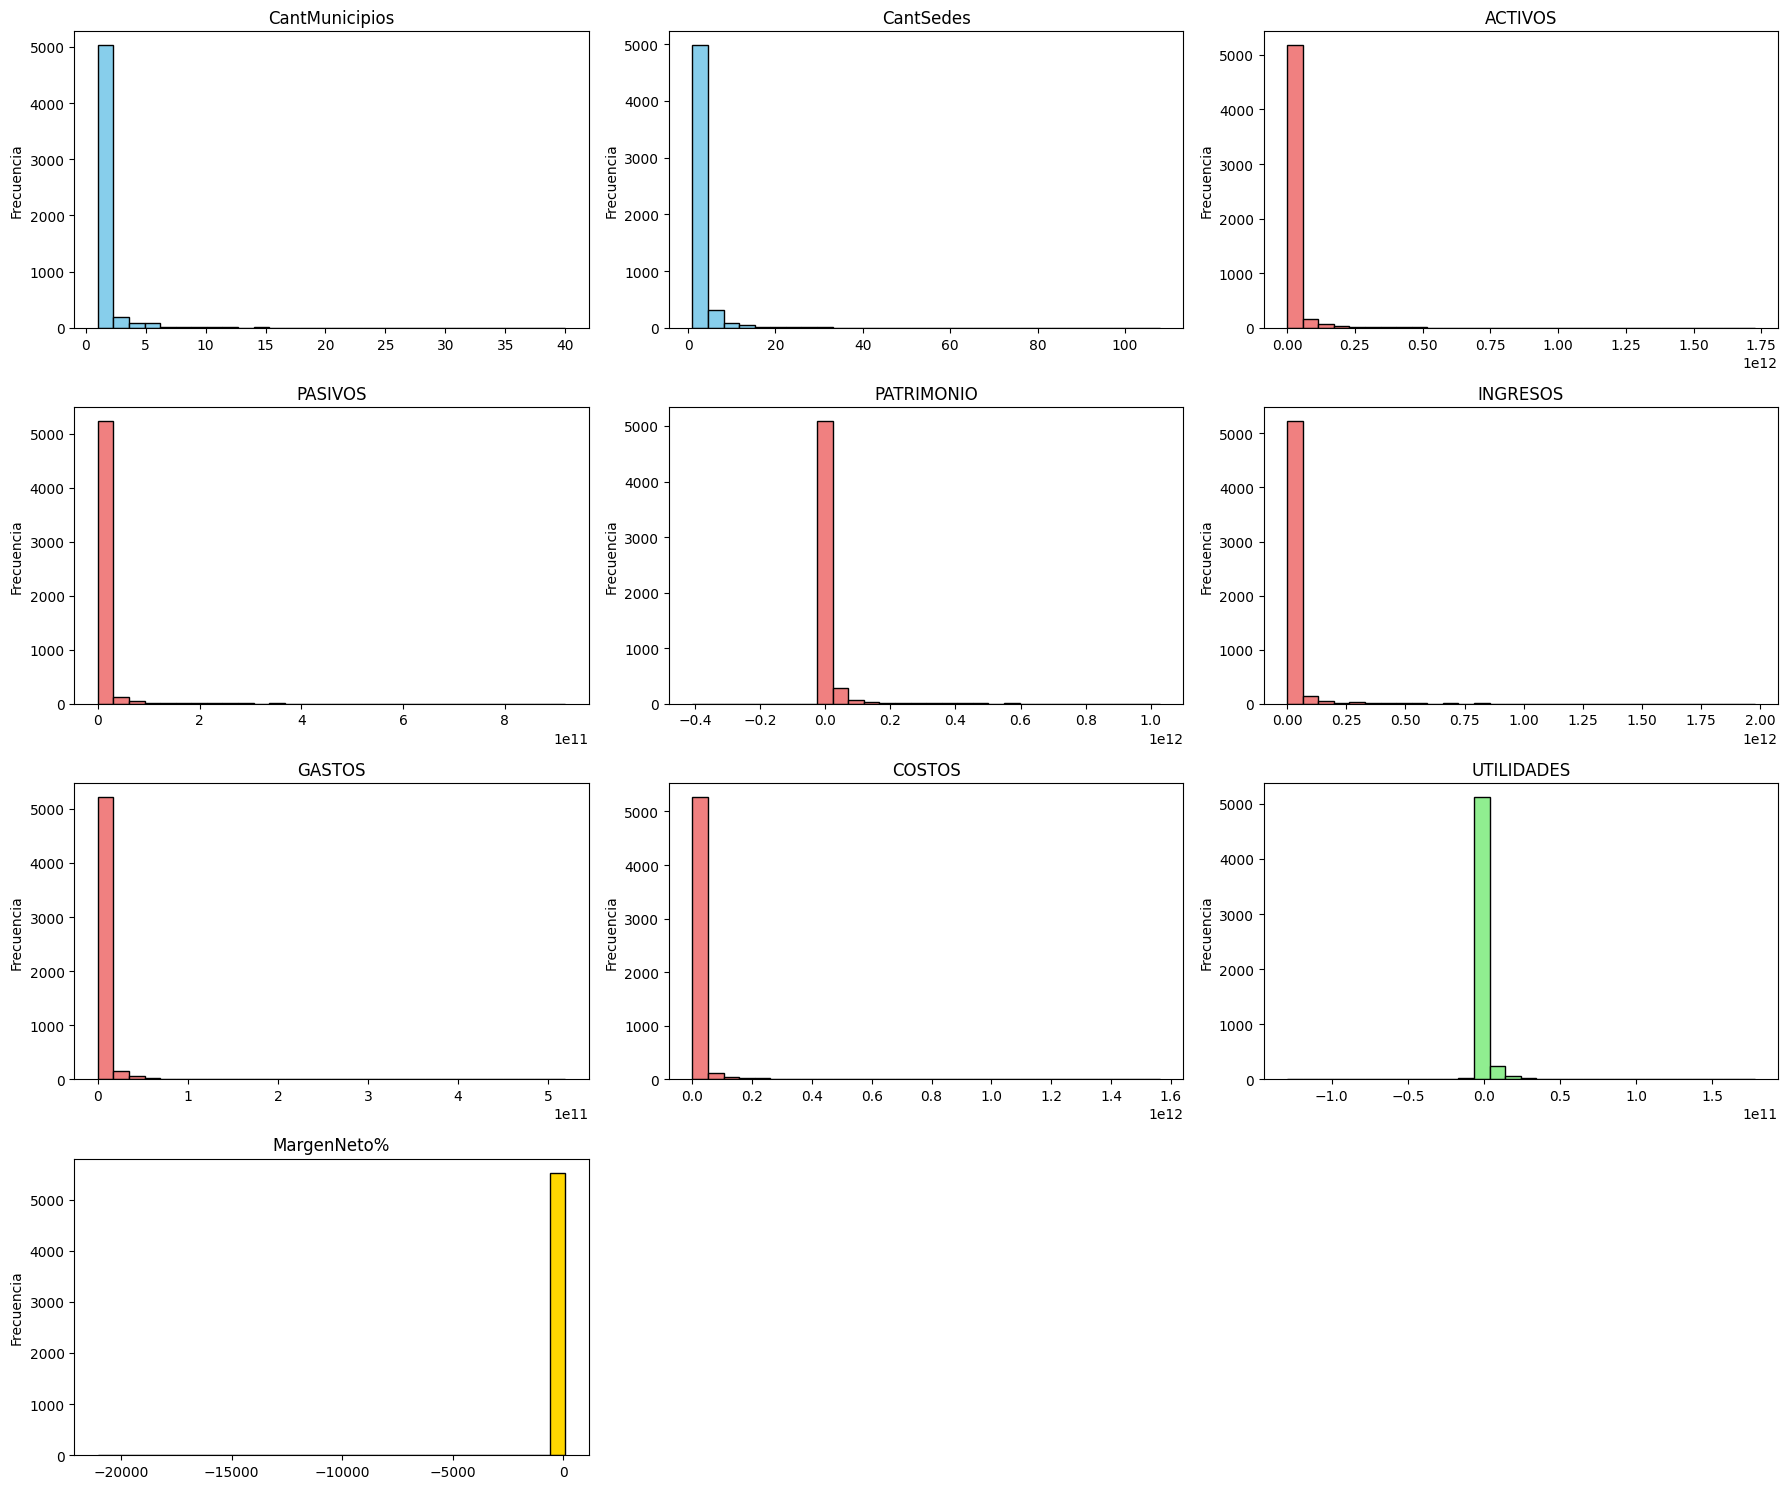

In [ ]:
#Histograma
plt.figure(figsize=(18,15))
#  olores por variable
colores = {
    # variables operativas
    'CantMunicipios': 'skyblue',
    'CantSedes': 'skyblue',
    
    # variables financieras
    'ACTIVOS': 'lightcoral',
    'PASIVOS': 'lightcoral',
    'PATRIMONIO': 'lightcoral',
    'INGRESOS': 'lightcoral',
    'GASTOS': 'lightcoral',
    'COSTOS': 'lightcoral',
    
    'UTILIDADES': 'lightgreen',
    
    'MargenNeto%': 'gold'
}
# crear histogramas
for i, columna in enumerate(X.columns, 1):
    plt.subplot(4,3,i)
    plt.hist(
        X[columna],
        bins=30,
        color=colores[columna],
        edgecolor='black'
    )
    plt.title(columna)
    plt.xlabel('')
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

#### Analisis
##### Los histogramas de las varibales dejan ver que la mayoria de varibales estan sesgadas hacia la parte derecha, indicando que muchas ips tiene desigualdad financiera, una gran cobertura regional y que muchas poseen rentabilidades pequeñas o ganancias y perdidas significativas.

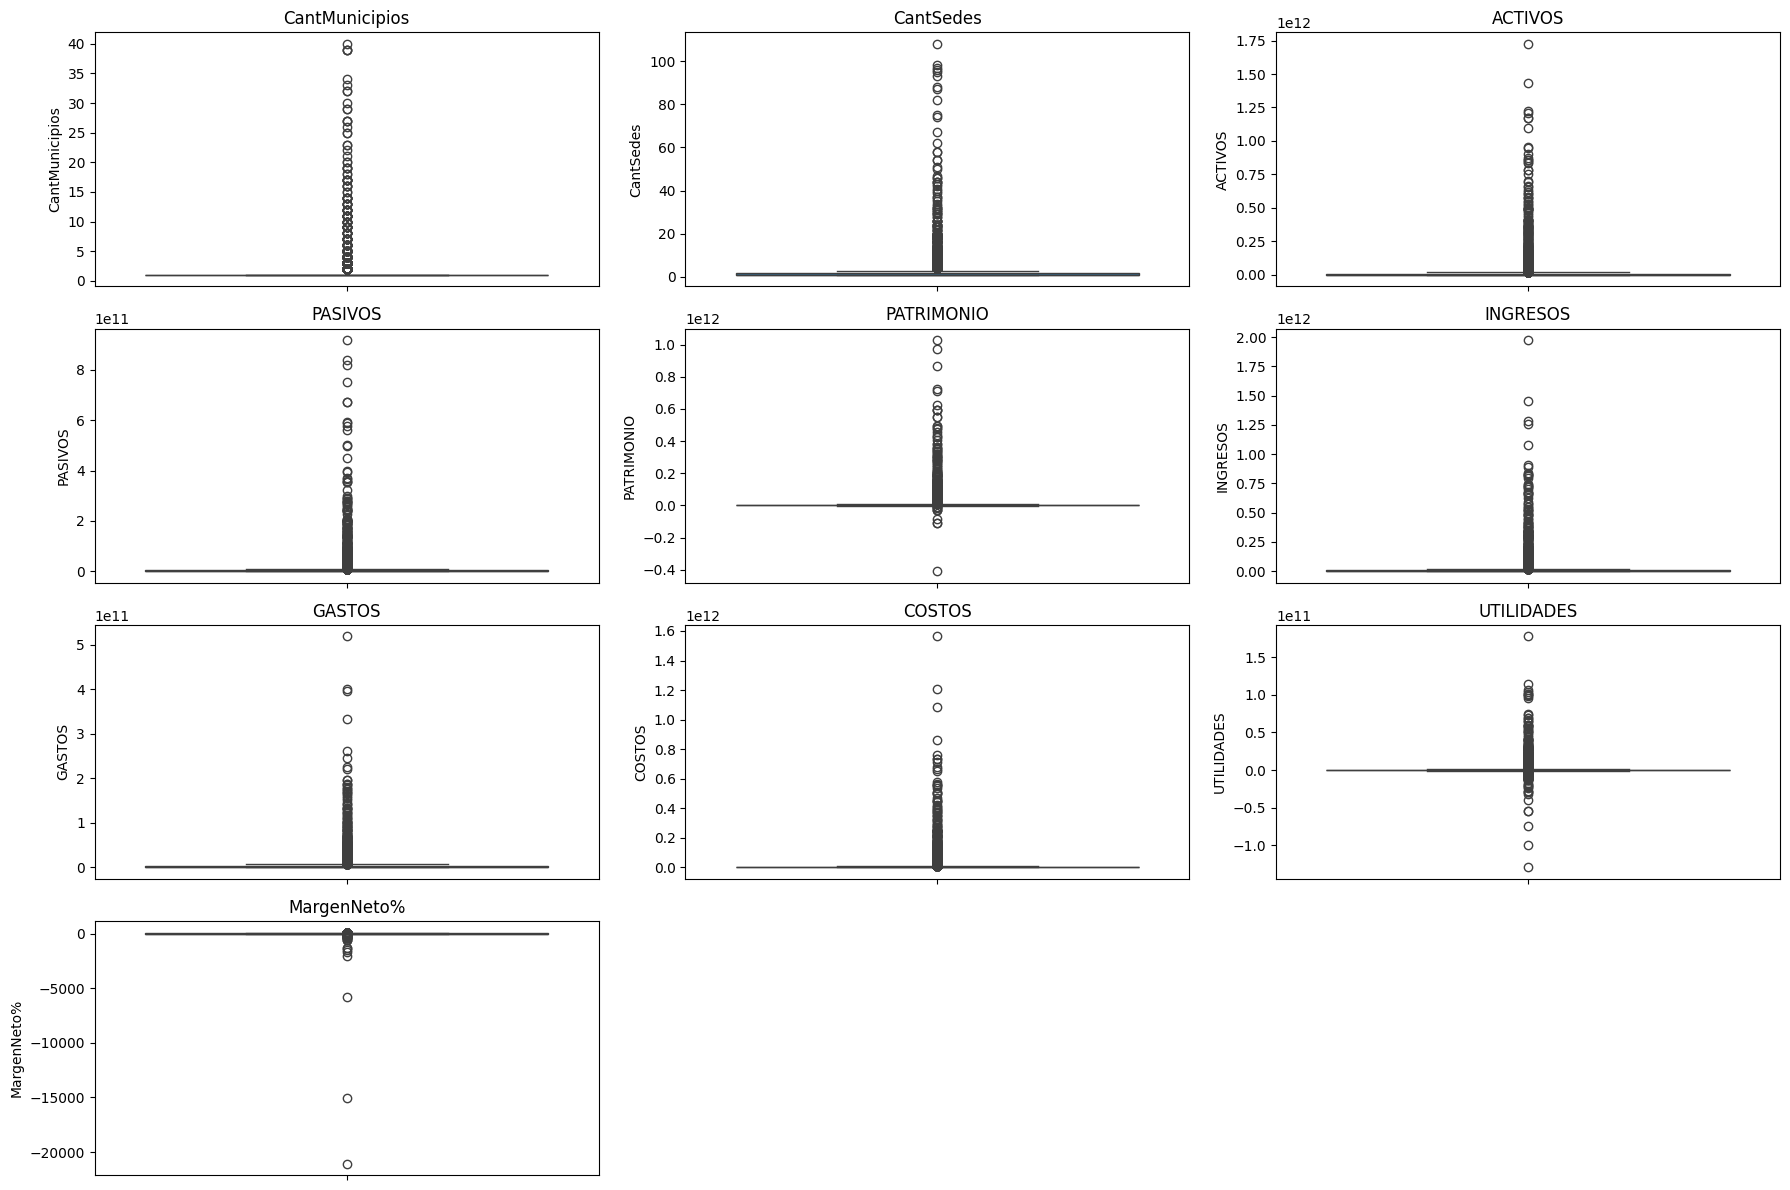

In [ ]:
# Boxplots
plt.figure(figsize=(18,12))
for i, columna in enumerate(X.columns, 1):
    plt.subplot(4,3,i)
    sns.boxplot(
        y=X[columna]
    )
    plt.title(columna)
plt.tight_layout()
plt.show()

#### Analisis
##### se evidencian muchos valores atipicos, indicando que existen ips significativamente mas grandes que el resto, con niveles financieros y operativos mayores.

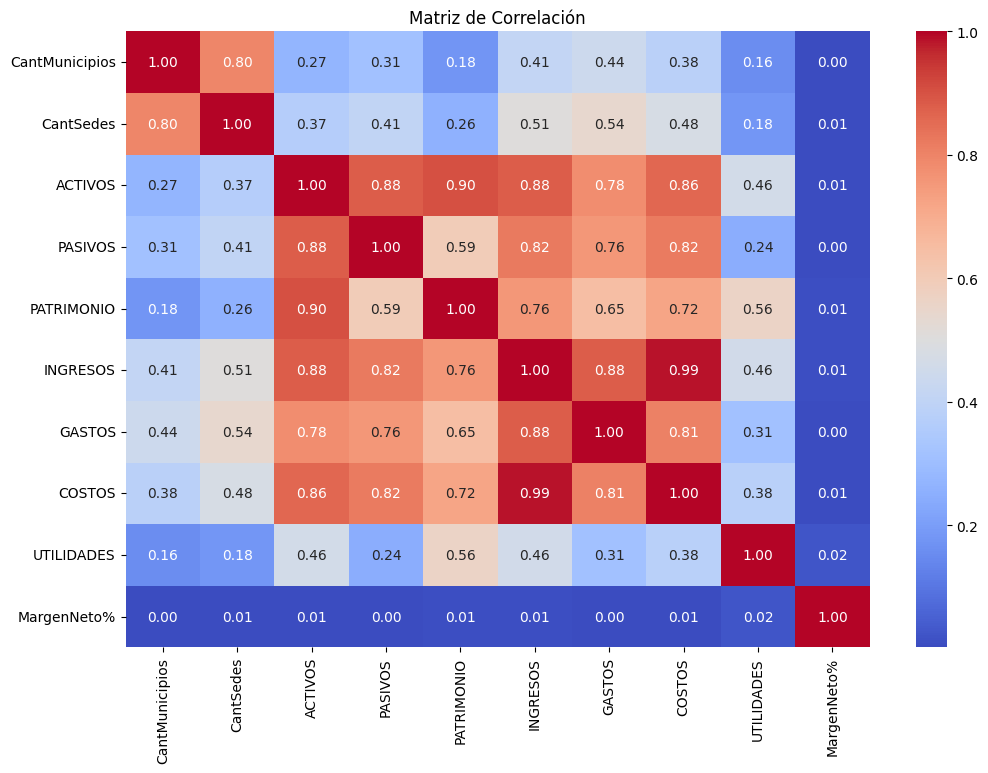

In [ ]:
# Matriz de correlacion 
correlacion = X.corr()
plt.figure(figsize=(12,8))
sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de correlacion')

# Mostrar
plt.show()

#### Analisis
##### Aqui se presentan varias correlaciones fuertes asociadas al tamaño y a la capacidad operativa de las ips, afirmando que las instituciones con mayores activos tienden a presentar mayores ingresos, costos y niveles de operacion, sin embargo, se evidencia tambien que el margen neto tiene correlacioens bajas, sugiriendo que depronto depende de factores distintos al tamaño. 
